# Import Libraries

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer , BitsAndBytesConfig
import torch

# Load Model In 4-Bit Quantization

In [2]:
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

In [3]:
tokenizer = AutoTokenizer.from_pretrained(r"A:\Qwen_2.5_7B")

In [4]:
tokenizer

Qwen2Tokenizer(name_or_path='A:\Qwen_2.5_7B', vocab_size=151643, model_max_length=32768, padding_side='left', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|vision_pad|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=False, lstrip=F

In [5]:
model = AutoModelForCausalLM.from_pretrained(
    r"A:\Qwen_2.5_7B",
    quantization_config=bnb,
    device_map={"": 0},
    dtype=torch.float16,
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

# Prompt and give one Example to model

In [29]:
prompt = """تو یک سیستم تحلیل احساسات فارسی هستی.
فقط یکی از این دو کلمه رو برگردون: 
- POSITIVE
- NEGATIVE

برای تصمیم‌گیری به این فاکتورها توجه کن:
1. ارزشیابی دانشجو (هرچی بالاتر، مثبت‌تر)
2. وضعیت نمره دادن
3. توضیحات دانشجو
4. حضور و غیاب
توجه : همه فاکتور ها مهم هستن و هر کدوم به تنهایی نباید باعث خروجی تو شود

نمونه‌ها:

نظر:
ارزیابی: 9,9,8,7,10,8
وضعیت نمره دادن: دست باز و با ارفاق
توضیحات: چیز اضافه ای نیست
احساس 

POSITIVE

نظر:
ارزیابی: 5,2,1,4,3,6
وضعیت نمره دادن: سخت گیر
توضیحات: چیز اضافه ای نیست
احساس 

NEGATIVE

--- حالا نوبت توئه ---

نظر:
"
    "منابع آموزش": "یک کتاب مرجع معرفی می کند",
    "حضور و غیاب": "حضور مهم است و تاثیر مستقیم دارد",
    "منابع معرفی شده برای امتحان کافی است": "تا حدودی",
    "وضعیت نمره دادن": "نمره خوبی نمیشه ازش گرفت",
    "ارزیابی دانشجو": {
      "پیوستگی و یکپارچگی تدریس": 8,
      "دانش عمومی": 10,
      "توانایی انتقال مطالب و نکات مهم درس": 8,
      "نحوه مدیریت کلاس(نظم و زمان)": 10,
      "پاسخگویی(حضوری و غیرحضوری)": 8,
      "آداب و رفتار اجتماعی با دانشجویان": 10
    },
    "توضیحات": "چیز اضافه ای نیست"
"

احساس:
"""

In [11]:
tokenized = tokenizer(prompt,return_tensors="pt").to("cuda")
tokenized

{'input_ids': tensor([[125203,    220,  14391,  32311,  59842,  14391,  46586,  10176,  39434,
         124552,  14391,   8532,  12961, 139296,  47632,  45577,  35038,  20064,
          14391,  55891,  46586,  14391,    624,  20931, 124687,    220,  14391,
          32311,  14391,  12961,  39697,  12961,  82255,  59842,  16157,  45593,
         124227,  16157, 131384, 129920,  63732,  11071, 127017,     25,    715,
             12,  26494,  44350,    198,     12,  84065,  23215,    198,     12,
           7856,   1381,  51731,    271,  83827,  46072, 130546,  10176,  14391,
          10176,  89364,  63732,  89820,  14391,  81768,  12961,  82255,  45577,
           5703,  32311, 131512, 124006,  39434, 127029,  45593,  11798,    510,
             16,     13,  12961, 132032,  32790,  14391,  70604,  14391,  44330,
          39423,  32790, 128655,    320, 124190, 144751,  14391, 124476,  47632,
          11071,  68785,  23364, 135445,  89364, 124015,    340,     17,     13,
         13051

In [12]:
output = tokenizer.decode(model.generate(**tokenized,max_new_tokens=3,eos_token_id=tokenizer.encode("\n")[0],temperature=0.1,do_sample=False),skip_special_tokens=True)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [13]:
print(output[0])

تو یک سیستم تحلیل احساسات فارسی هستی.
فقط یکی از این سه کلمه رو برگردون: 
- POSITIVE
- NEGATIVE
- NEUTRAL

برای تصمیم‌گیری به این فاکتورها توجه کن:
1. ارزشیابی دانشجو (هرچی بالاتر، مثبت‌تر)
2. وضعیت نمره دادن
3. توضیحات دانشجو
4. حضور و غیاب
توجه : همه فاکتور ها مهم هستن و هر کدوم به تنهایی نباید باعث خروجی تو شود

نمونه‌ها:

نظر:
ارزیابی: 9,9,8,7,10,8
وضعیت نمره دادن: دست باز و با ارفاق
توضیحات: چیز اضافه ای نیست
احساس 

POSITIVE

نظر:
ارزیابی: 5,2,1,4,3,6
وضعیت نمره دادن: سخت گیر
توضیحات: چیز اضافه ای نیست
احساس 

NEGATIVE

--- حالا نوبت توئه ---

نظر:
"
    "منابع آموزش": "یک کتاب مرجع معرفی می کند",
    "حضور و غیاب": "حضور مهم است و تاثیر مستقیم دارد",
    "منابع معرفی شده برای امتحان کافی است": "تا حدودی",
    "وضعیت نمره دادن": "نمره خوبی نمیشه ازش گرفت",
    "ارزیابی دانشجو": {
      "پیوستگی و یکپارچگی تدریس": 8,
      "دانش عمومی": 10,
      "توانایی انتقال مطالب و نکات مهم درس": 8,
      "نحوه مدیریت کلاس(نظم و زمان)": 10,
      "پاسخگویی(حضوری و غیرحضوری)": 8,
      "آداب و

# Open Reviwes File

In [7]:
import json

with open("reviews_fa.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

In [8]:
len(dataset)

2577

In [8]:
res = {}
unknown = []

# Assigning values to all 6 factors

In [9]:
def get_evaluation(d):
    evaluation = d.get("ارزیابی دانشجو", {})
    values = list(evaluation.values())
    avg = int(sum(values) / len(values)) if values else 5
    
    keys = [
        "پیوستگی و یکپارچگی تدریس",
        "دانش عمومی",
        "توانایی انتقال مطالب و نکات مهم درس",
        "نحوه مدیریت کلاس(نظم و زمان)",
        "پاسخگویی(حضوری و غیرحضوری)",
        "آداب و رفتار اجتماعی با دانشجویان"
    ]
    
    return [evaluation.get(k, avg) for k in keys]

# Make Final Dataset With Pos/Neg

In [11]:
def make_res(model,dataset,res,start,end):

    for i,d in enumerate(dataset):

        if (i < start):
            continue

        else:
        
            name_os = list(d.values())[1]
            name_dars = list(d.values())[2]
            name_danesh = list(d.values())[3]
        
            if name_danesh not in res:
                res[name_danesh] = {}
                
            if name_os not in res[name_danesh]:
                res[name_danesh][name_os] = {}
                
            if name_dars not in res[name_danesh][name_os]:
                res[name_danesh][name_os][name_dars] = {
                    "نظرات" : []
                }
    
    
            ev = get_evaluation(d)
            prompt = f"""تو یک سیستم تحلیل احساسات فارسی هستی.
فقط یکی از این دو کلمه رو برگردون: 
- POSITIVE
- NEGATIVE

برای تصمیم‌گیری به این فاکتورها توجه کن:
1. ارزشیابی دانشجو (هرچی بالاتر، مثبت‌تر)
2. وضعیت نمره دادن
3. توضیحات دانشجو
4. حضور و غیاب
توجه : همه فاکتور ها مهم هستن و هر کدوم به تنهایی نباید باعث خروجی تو شود

نمونه‌ها:

نظر:
ارزیابی: 9,9,8,7,10,8
وضعیت نمره دادن: دست باز و با ارفاق
توضیحات: چیز اضافه ای نیست
احساس 

POSITIVE

نظر:
ارزیابی: 5,2,1,4,3,6
وضعیت نمره دادن: سخت گیر
توضیحات: چیز اضافه ای نیست
احساس 

NEGATIVE

--- حالا نوبت توئه ---
        
نظر:
"
"منابع آموزش": "{list(d.values())[4]}",
"حضور و غیاب": "{list(d.values())[5]}",
"منابع معرفی شده برای امتحان کافی است": "{list(d.values())[6]}",
"وضعیت نمره دادن": "{list(d.values())[7]}",
"ارزیابی دانشجو": [
    "پیوستگی و یکپارچگی تدریس": {ev[0]},
    "دانش عمومی": {ev[1]},
    "توانایی انتقال مطالب و نکات مهم درس": {ev[2]},
    "نحوه مدیریت کلاس(نظم و زمان)": {ev[3]},
    "پاسخگویی(حضوری و غیرحضوری)": {ev[4]},
    "آداب و رفتار اجتماعی با دانشجویان": {ev[5]}
],
"توضیحات": "چیز اضافه ای نیست"
"
        
احساس:
        
        """
            
            tokenized = tokenizer(prompt,return_tensors="pt").to("cuda")
            generated = tokenizer.decode(model.generate(**tokenized,max_new_tokens=3,eos_token_id=tokenizer.encode("\n")[0],temperature=0.1,do_sample=False),skip_special_tokens=True)
            if "احساس:" in generated[0]:
                sentiment = generated[0].split("احساس:")[-1].strip().split()[0]
            else:
                sentiment = generated[0].strip().split()[0]
    
            valid = ["POSITIVE", "NEGATIVE", "NEUTRAL"]
            if sentiment not in valid:
                unknown.append(d)
                
            else :
                res[name_danesh][name_os][name_dars]["نظرات"].append(sentiment)
    
            if (i == end):
                break
    
        print(f"{i} was finished!")

    
    if unknown:
        with open("unknown.json", "w", encoding="utf-8") as f:
            json.dump(unknown, f, ensure_ascii=False, indent=2)

In [12]:
make_res(model,dataset,res,0,2576)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


0 was finished!
1 was finished!
2 was finished!
3 was finished!
4 was finished!
5 was finished!
6 was finished!
7 was finished!
8 was finished!
9 was finished!
10 was finished!
11 was finished!
12 was finished!
13 was finished!
14 was finished!
15 was finished!
16 was finished!
17 was finished!
18 was finished!
19 was finished!
20 was finished!
21 was finished!
22 was finished!
23 was finished!
24 was finished!
25 was finished!
26 was finished!
27 was finished!
28 was finished!
29 was finished!
30 was finished!
31 was finished!
32 was finished!
33 was finished!
34 was finished!
35 was finished!
36 was finished!
37 was finished!
38 was finished!
39 was finished!
40 was finished!
41 was finished!
42 was finished!
43 was finished!
44 was finished!
45 was finished!
46 was finished!
47 was finished!
48 was finished!
49 was finished!
50 was finished!
51 was finished!
52 was finished!
53 was finished!
54 was finished!
55 was finished!
56 was finished!
57 was finished!
58 was finished!
59 was 

In [13]:
print(res)

{'علوم و فناوری های زیستی': {'فریبا دهقانیان': {'ژنتیک پایه': {'نظرات': ['POSITIVE']}}, 'روح الله عباسی': {'مبانی جانورشناسی': {'نظرات': ['POSITIVE', 'POSITIVE']}, 'مبانی زیست شناسی جانوری': {'نظرات': ['POSITIVE']}, 'مبانی جانور شناسی': {'نظرات': ['POSITIVE']}, 'جانورشناسی': {'نظرات': ['POSITIVE']}}, 'بهرام یداللهی': {'شیمی عمومی': {'نظرات': ['NEGATIVE']}}, 'علی باقری': {'مبانی گیاه شناسی': {'نظرات': ['POSITIVE', 'POSITIVE', 'POSITIVE']}}, 'سعید افشارزاده': {'مبانی بوم شناسی': {'نظرات': ['NEGATIVE']}}, 'مریم حاجیان': {'آزمایشگاه جانور': {'نظرات': ['NEGATIVE']}, 'آزمایشگاه مبانی جانورشناسی': {'نظرات': ['POSITIVE']}, 'آزمایشگاه مبانی جانوری شناسی': {'نظرات': ['POSITIVE']}}, 'روح اله عباسی': {'جانورشناسی بی مهرگان': {'نظرات': ['POSITIVE']}}, 'محمدرضا گنجعلی\u200cخانی': {'بیوفیزیک': {'نظرات': ['POSITIVE']}}, 'احسان حکیمیان': {'ریاضی': {'نظرات': ['NEGATIVE']}, 'ریاضی1': {'نظرات': ['NEGATIVE']}, 'ریاضی عمومی': {'نظرات': ['NEGATIVE', 'NEGATIVE']}}, 'احسان حكيميان': {'رياضي عمومي': {'نظرات': [

# Open Final File For Fix Some Bugs Of Structure And Fix Them
The Problem Is We Had For Example ("ریاضی 1") and ("ریاضی عمومی 1") But They Are Same . So We Use Embedding Model And Cosine Simularity For Fix This Problem And Merge Them.

In [14]:
with open("results_new.json", "w", encoding="utf-8") as f:
    json.dump(res, f, ensure_ascii=False, indent=2)

In [15]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from thefuzz import fuzz
import numpy as np
import json

embedder = SentenceTransformer(r"B:\MiniLM")

cache = {}

def get_embedding(text):
    if text not in cache:
        cache[text] = embedder.encode([text])[0]
    return cache[text]

def find_similar(name, existing_names, fuzz_threshold=75, semantic_threshold=0.82):
    if not existing_names:
        return None
    
    name_emb = get_embedding(name).reshape(1, -1)
    existing_embs = np.array([get_embedding(n) for n in existing_names])
    scores = cosine_similarity(name_emb, existing_embs)[0]
    best_idx = np.argmax(scores)
    best_name = existing_names[best_idx]
    
    # partial_ratio به جای ratio
    fuzz_score = fuzz.partial_ratio(name, best_name)
    semantic_score = scores[best_idx]
    
    # یکی از دو تا کافیه
    if fuzz_score >= fuzz_threshold or semantic_score >= semantic_threshold:
        return best_name
    return None

def merge_results(data, prof_threshold=0.92, course_threshold=0.88):
    merged = {}
    
    for faculty, professors in data.items():
        if not faculty:
            continue
        
        similar_faculty = find_similar(faculty, list(merged.keys()), semantic_threshold=0.95)
        faculty_key = similar_faculty if similar_faculty else faculty
        
        if faculty_key not in merged:
            merged[faculty_key] = {}
        
        for prof, courses in professors.items():
            if not prof:
                continue
            
            similar_prof = find_similar(prof, list(merged[faculty_key].keys()), semantic_threshold=prof_threshold)
            prof_key = similar_prof if similar_prof else prof
            
            if prof_key not in merged[faculty_key]:
                merged[faculty_key][prof_key] = {}
            
            for course, content in courses.items():
                if not course:
                    continue
                
                similar_course = find_similar(course, list(merged[faculty_key][prof_key].keys()), semantic_threshold=course_threshold)
                course_key = similar_course if similar_course else course
                
                if course_key not in merged[faculty_key][prof_key]:
                    merged[faculty_key][prof_key][course_key] = {"نظرات": []}
                
                merged[faculty_key][prof_key][course_key]["نظرات"].extend(content["نظرات"])
    
    return merged

print("در حال لود فایل...")
with open("results_new.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("در حال ادغام...")
merged = merge_results(data)

with open("merged_results_new.json", "w", encoding="utf-8") as f:
    json.dump(merged, f, ensure_ascii=False, indent=2)

print("تموم شد!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

در حال لود فایل...
در حال ادغام...
تموم شد!


# Set Evaluation Dataset (On 200 Samples)

In [6]:
labels = ['POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE']

print(len(labels))

200


In [7]:
preds = []

In [8]:
import json

with open("original_200.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

In [9]:
def make_res_for_eval(model,dataset,preds):

    for i,d in enumerate(dataset):

        
        name_os = list(d.values())[1]
        name_dars = list(d.values())[2]
        name_danesh = list(d.values())[3]
    


        ev = get_evaluation(d)
        prompt = f"""تو یک سیستم تحلیل احساسات فارسی هستی.
فقط یکی از این دو کلمه رو برگردون: 
- POSITIVE
- NEGATIVE

برای تصمیم‌گیری به این فاکتورها توجه کن:
1. ارزشیابی دانشجو (هرچی بالاتر، مثبت‌تر)
2. وضعیت نمره دادن
3. توضیحات دانشجو
4. حضور و غیاب
توجه : همه فاکتور ها مهم هستن و هر کدوم به تنهایی نباید باعث خروجی تو شود

نمونه‌ها:

نظر:
ارزیابی: 9,9,8,7,10,8
وضعیت نمره دادن: دست باز و با ارفاق
توضیحات: چیز اضافه ای نیست
احساس 

POSITIVE

نظر:
ارزیابی: 5,2,1,4,3,6
وضعیت نمره دادن: سخت گیر
توضیحات: چیز اضافه ای نیست
احساس 

NEGATIVE

--- حالا نوبت توئه ---
    
نظر:
"
"منابع آموزش": "{list(d.values())[4]}",
"حضور و غیاب": "{list(d.values())[5]}",
"منابع معرفی شده برای امتحان کافی است": "{list(d.values())[6]}",
"وضعیت نمره دادن": "{list(d.values())[7]}",
"ارزیابی دانشجو": [
"پیوستگی و یکپارچگی تدریس": {ev[0]},
"دانش عمومی": {ev[1]},
"توانایی انتقال مطالب و نکات مهم درس": {ev[2]},
"نحوه مدیریت کلاس(نظم و زمان)": {ev[3]},
"پاسخگویی(حضوری و غیرحضوری)": {ev[4]},
"آداب و رفتار اجتماعی با دانشجویان": {ev[5]}
],
"توضیحات": "چیز اضافه ای نیست"
"
    
احساس:
    
    """
        
        tokenized = tokenizer(prompt,return_tensors="pt").to("cuda")
        generated = tokenizer.decode(model.generate(**tokenized,max_new_tokens=3,eos_token_id=tokenizer.encode("\n")[0],temperature=0.1,do_sample=False),skip_special_tokens=True)
        if "احساس:" in generated[0]:
            sentiment = generated[0].split("احساس:")[-1].strip().split()[0]
        else:
            sentiment = generated[0].strip().split()[0]

        valid = ["POSITIVE", "NEGATIVE"]
        if sentiment not in valid:
            unknown.append(d)
            
        else :
            preds.append(sentiment)


        print(f"{i} was finished!")

    
    if unknown:
        with open("unknown.json", "w", encoding="utf-8") as f:
            json.dump(unknown, f, ensure_ascii=False, indent=2)

In [14]:
make_res_for_eval(model,dataset,preds)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


0 was finished!
1 was finished!
2 was finished!
3 was finished!
4 was finished!
5 was finished!
6 was finished!
7 was finished!
8 was finished!
9 was finished!
10 was finished!
11 was finished!
12 was finished!
13 was finished!
14 was finished!
15 was finished!
16 was finished!
17 was finished!
18 was finished!
19 was finished!
20 was finished!
21 was finished!
22 was finished!
23 was finished!
24 was finished!
25 was finished!
26 was finished!
27 was finished!
28 was finished!
29 was finished!
30 was finished!
31 was finished!
32 was finished!
33 was finished!
34 was finished!
35 was finished!
36 was finished!
37 was finished!
38 was finished!
39 was finished!
40 was finished!
41 was finished!
42 was finished!
43 was finished!
44 was finished!
45 was finished!
46 was finished!
47 was finished!
48 was finished!
49 was finished!
50 was finished!
51 was finished!
52 was finished!
53 was finished!
54 was finished!
55 was finished!
56 was finished!
57 was finished!
58 was finished!
59 was 

# Evaluate with accuracy/recall/precision

In [1]:
import evaluate

metric = evaluate.load("accuracy")
metric2 = evaluate.load("recall")
metric3 = evaluate.load("precision")

In [15]:
preds_int = []

for i in preds:
    if i == "POSITIVE" :
        preds_int.append(1)
        
    else : preds_int.append(0)

In [16]:
labels_int = []

for i in labels:
    if i == "POSITIVE" :
        labels_int.append(1)

    else : 
        labels_int.append(0)

In [19]:
print(metric.compute(predictions=preds_int,references=labels_int))
print(metric2.compute(predictions=preds_int, references=labels_int, average="macro"))
print(metric3.compute(predictions=preds_int, references=labels_int, average="macro"))

{'accuracy': 0.92}
{'recall': 0.8523908523908523}
{'precision': 0.9405458089668617}


# Confusion Maxtrix For Catch Some Ideas of Our Metrics

In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
matrix = confusion_matrix(labels,preds,labels=["NEGATIVE","POSITIVE"])
matrix

array([[ 37,  15],
       [  1, 147]])

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 23.52222222222222, 'Prediction')

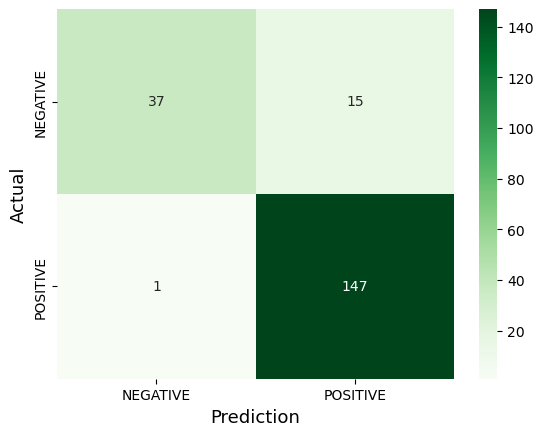

In [23]:
sns.heatmap(matrix, annot=True, fmt='g',cmap="Greens",xticklabels=['NEGATIVE', 'POSITIVE'],yticklabels=['NEGATIVE', 'POSITIVE'])
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)

# Print Wrong Generation Of model on Evaluation Dataset

In [24]:
for i in range(200):
    if (preds_int[i] != labels_int[i]):
        print(f"Real : {labels[i]} \nmodel : {preds[i]} \nshomare : {i+1} \n---------------------------")

Real : NEGATIVE 
model : POSITIVE 
shomare : 9 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 15 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 17 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 18 
---------------------------
Real : POSITIVE 
model : NEGATIVE 
shomare : 32 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 80 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 92 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 103 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 165 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 166 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 167 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 180 
---------------------------
Real : NEGATIVE 
model : POSITIVE 
shomare : 183 
----------------------

# Note :
. We Had A Few Prompt That Use For This Project But All Of Them Have Model Generation Time Around 60-70 Seconds Per Sample So We Use Prompt Engineering And Solve This Problem And Decrease The Time To Around 3-4 Seconds Per Sample ! Yeah We Are Championnnnn :)